In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)

In [2]:
from sklearn.model_selection import train_test_split

DATA_DIR = Path("../data/interim")

features = pd.read_csv(
    DATA_DIR / "customer_features.csv"
)

labels = pd.read_csv(
    DATA_DIR / "churn_labels.csv"
)

model_data = features.merge(
    labels,
    on="user_id",
    how="inner",
    validate="one_to_one",
)

TARGET = "churn_like_label"
ID_COLUMN = "user_id"

X = model_data.drop(
    columns=[ID_COLUMN, TARGET]
)

y = model_data[TARGET].astype("int8")

In [3]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp,
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (144329, 23)
Validation: (30928, 23)
Test: (30928, 23)


In [4]:
dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(
    X_train,
    y_train
)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
Name,Type,Value
"class_prior_ class_prior_: ndarray of shape (n_classes,) or list of such arraysFrequency of each class observed in `y`. For multioutput classificationproblems, this is computed independently for each output.","ndarray[float64](2,)","[0.79,0.21]"
"classes_ classes_: ndarray of shape (n_classes,) or list of such arraysUnique class labels observed in `y`. For multi-output classificationproblems, this attribute is a list of arrays as each output has anindependent set of possible classes.","ndarray[int8](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` hasfeature names that are all strings.","ndarray[object](23,)","['total_orders','max_order_number','avg_days_between_orders',..., 'dominant_aisle_share','inactivity_gap','inactivity_ratio']"
n_classes_ n_classes_: int or list of intNumber of label for each output.,int,2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,23
n_outputs_ n_outputs_: intNumber of outputs.,int,1
sparse_output_ sparse_output_: boolTrue if the array returned from predict is to be in sparse CSC format.Is automatically set to True if the input `y` is passed in sparseformat.,bool,False


In [5]:
y_val_pred = dummy_model.predict(X_val)

In [6]:
baseline_results = {
    "Accuracy": accuracy_score(y_val, y_val_pred),
    "Precision": precision_score(
        y_val,
        y_val_pred,
        zero_division=0,
    ),
    "Recall": recall_score(
        y_val,
        y_val_pred,
        zero_division=0,
    ),
    "F1": f1_score(
        y_val,
        y_val_pred,
        zero_division=0,
    ),
}

baseline_results

{'Accuracy': 0.7906751163993792, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}

In [7]:
cm = confusion_matrix(
    y_val,
    y_val_pred
)

cm

array([[24454,     0],
       [ 6474,     0]])

## Candidate Model Training

Candidate models are trained using preprocessing pipelines appropriate to their algorithmic requirements.

Logistic Regression requires numerical features on a comparable scale, so median imputation and standardization are included inside the model pipeline.

The validation set is used for initial model comparison, while the test set remains reserved for final evaluation.

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [9]:
logistic_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        ),
    ]
)

In [10]:
logistic_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int8](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](23,)","['total_orders','max_order_number','avg_days_between_orders',..., 'dominant_aisle_share','inactivity_gap','inactivity_ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,23
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace 

In [11]:
y_val_pred_lr = logistic_pipeline.predict(X_val)
y_val_prob_lr = logistic_pipeline.predict_proba(X_val)[:, 1]

In [12]:
logistic_results = {
    "Accuracy": accuracy_score(
        y_val,
        y_val_pred_lr
    ),
    "Precision": precision_score(
        y_val,
        y_val_pred_lr,
        zero_division=0
    ),
    "Recall": recall_score(
        y_val,
        y_val_pred_lr,
        zero_division=0
    ),
    "F1": f1_score(
        y_val,
        y_val_pred_lr,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_val,
        y_val_prob_lr
    ),
    "PR-AUC": average_precision_score(
        y_val,
        y_val_prob_lr
    ),
}

logistic_results

{'Accuracy': 0.7980794102431453,
 'Precision': 0.5406460773872914,
 'Recall': 0.23524868705591598,
 'F1': 0.32784415025293295,
 'ROC-AUC': 0.8113277009744535,
 'PR-AUC': 0.47235855949459976}

In [13]:
from sklearn.ensemble import RandomForestClassifier

In [14]:
random_forest_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                n_jobs=1,
                class_weight="balanced"
            )
        ),
    ]
)

In [15]:
random_forest_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int8](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](23,)","['total_orders','max_order_number','avg_days_between_orders',..., 'dominant_aisle_share','inactivity_gap','inactivity_ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,23
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace allocc

In [16]:
y_val_pred_rf = random_forest_pipeline.predict(X_val)

y_val_prob_rf = (
    random_forest_pipeline
    .predict_proba(X_val)[:, 1]
)

In [17]:
random_forest_results = {
    "Accuracy": accuracy_score(
        y_val,
        y_val_pred_rf,
    ),
    "Precision": precision_score(
        y_val,
        y_val_pred_rf,
        zero_division=0,
    ),
    "Recall": recall_score(
        y_val,
        y_val_pred_rf,
        zero_division=0,
    ),
    "F1": f1_score(
        y_val,
        y_val_pred_rf,
        zero_division=0,
    ),
    "ROC-AUC": roc_auc_score(
        y_val,
        y_val_prob_rf,
    ),
    "PR-AUC": average_precision_score(
        y_val,
        y_val_prob_rf,
    ),
}

random_forest_results

{'Accuracy': 0.7608316088980859,
 'Precision': 0.44905618721713214,
 'Recall': 0.6283595922150139,
 'F1': 0.5237880641215477,
 'ROC-AUC': 0.8301931515152847,
 'PR-AUC': 0.47662745764572345}

## Extra Trees

In [18]:
from sklearn.ensemble import ExtraTreesClassifier

In [19]:
extra_trees_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "model",
            ExtraTreesClassifier(
                n_estimators=300,
                random_state=42,
                n_jobs=-1,
                class_weight="balanced"
            )
        ),
    ]
)

In [20]:
extra_trees_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int8](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](23,)","['total_orders','max_order_number','avg_days_between_orders',..., 'dominant_aisle_share','inactivity_gap','inactivity_ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,23
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace allocc

In [21]:
y_val_pred_et = extra_trees_pipeline.predict(X_val)

y_val_prob_et = (
    extra_trees_pipeline
    .predict_proba(X_val)[:, 1]
)

In [22]:
extra_trees_results = {
    "Accuracy": accuracy_score(
        y_val,
        y_val_pred_et,
    ),
    "Precision": precision_score(
        y_val,
        y_val_pred_et,
        zero_division=0,
    ),
    "Recall": recall_score(
        y_val,
        y_val_pred_et,
        zero_division=0,
    ),
    "F1": f1_score(
        y_val,
        y_val_pred_et,
        zero_division=0,
    ),
    "ROC-AUC": roc_auc_score(
        y_val,
        y_val_prob_et,
    ),
    "PR-AUC": average_precision_score(
        y_val,
        y_val_prob_et,
    ),
}

extra_trees_results

{'Accuracy': 0.7960424211070875,
 'Precision': 0.5313444108761329,
 'Recall': 0.21733086190917517,
 'F1': 0.30848498136373603,
 'ROC-AUC': 0.8280354780345912,
 'PR-AUC': 0.4781660996551349}

## HistGradientBoosting

In [23]:
from sklearn.ensemble import HistGradientBoostingClassifier

In [24]:
hist_gb_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "model",
            HistGradientBoostingClassifier(
                max_iter=300,
                random_state=42
            )
        ),
    ]
)

In [25]:
hist_gb_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int8](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](23,)","['total_orders','max_order_number','avg_days_between_orders',..., 'dominant_aisle_share','inactivity_gap','inactivity_ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,23
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace allocc

In [26]:
y_val_pred_hgb = hist_gb_pipeline.predict(X_val)

y_val_prob_hgb = (
    hist_gb_pipeline
    .predict_proba(X_val)[:, 1]
)

In [27]:
hist_gb_results = {
    "Accuracy": accuracy_score(
        y_val,
        y_val_pred_hgb,
    ),
    "Precision": precision_score(
        y_val,
        y_val_pred_hgb,
        zero_division=0,
    ),
    "Recall": recall_score(
        y_val,
        y_val_pred_hgb,
        zero_division=0,
    ),
    "F1": f1_score(
        y_val,
        y_val_pred_hgb,
        zero_division=0,
    ),
    "ROC-AUC": roc_auc_score(
        y_val,
        y_val_prob_hgb,
    ),
    "PR-AUC": average_precision_score(
        y_val,
        y_val_prob_hgb,
    ),
}

hist_gb_results

{'Accuracy': 0.7994374030005174,
 'Precision': 0.5581295581295581,
 'Recall': 0.20095767686129132,
 'F1': 0.2955139125496877,
 'ROC-AUC': 0.8375694554299135,
 'PR-AUC': 0.5022704442275266}

## XGBoost

In [28]:
from xgboost import XGBClassifier

In [29]:
xgb_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "model",
            XGBClassifier(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=6,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=1,
            )
        ),
    ]
)

In [30]:
xgb_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](23,)","['total_orders','max_order_number','avg_days_between_orders',..., 'dominant_aisle_share','inactivity_gap','inactivity_ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,23
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloc

In [31]:
y_val_pred_xgb = xgb_pipeline.predict(X_val)

y_val_prob_xgb = (
    xgb_pipeline
    .predict_proba(X_val)[:, 1]
)

In [32]:
xgb_results = {
    "Accuracy": accuracy_score(
        y_val,
        y_val_pred_xgb,
    ),
    "Precision": precision_score(
        y_val,
        y_val_pred_xgb,
        zero_division=0,
    ),
    "Recall": recall_score(
        y_val,
        y_val_pred_xgb,
        zero_division=0,
    ),
    "F1": f1_score(
        y_val,
        y_val_pred_xgb,
        zero_division=0,
    ),
    "ROC-AUC": roc_auc_score(
        y_val,
        y_val_prob_xgb,
    ),
    "PR-AUC": average_precision_score(
        y_val,
        y_val_prob_xgb,
    ),
}

xgb_results

{'Accuracy': 0.8001810657009829,
 'Precision': 0.5608947804473903,
 'Recall': 0.20914426938523323,
 'F1': 0.30468046804680465,
 'ROC-AUC': 0.8379613634814943,
 'PR-AUC': 0.501985418997213}

In [33]:
model_results = pd.DataFrame(
    [
        {"Model": "Dummy Baseline", **baseline_results},
        {"Model": "Logistic Regression", **logistic_results},
        {"Model": "Random Forest", **random_forest_results},
        {"Model": "Extra Trees", **extra_trees_results},
        {"Model": "HistGradientBoosting", **hist_gb_results},
        {"Model": "XGBoost", **xgb_results},
    ]
)

model_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Dummy Baseline,0.790675,0.000000,0.000000,0.000000,NaN,NaN
1,Logistic Regression,0.798079,0.540646,0.235249,0.327844,0.811328,0.472359
2,Random Forest,0.760832,0.449056,0.628360,0.523788,0.830193,0.476627
3,Extra Trees,0.796042,0.531344,0.217331,0.308485,0.828035,0.478166
4,HistGradientBoosting,0.799437,0.558130,0.200958,0.295514,0.837569,0.502270
5,XGBoost,0.800181,0.560895,0.209144,0.304680,0.837961,0.501985


## Cross-Validation

Stratified K-fold cross-validation is used to assess the stability of candidate model performance across multiple training and validation folds.

Stratification preserves the churn-like class distribution in every fold.

Preprocessing remains inside each model pipeline so that imputation and scaling are fitted independently within each training fold, preventing cross-validation leakage.

The held-out test set remains untouched.


In [34]:
from sklearn.model_selection import StratifiedKFold, cross_validate

In [35]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [36]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
}

In [37]:
lr_cv = cross_validate(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=1,
    return_train_score=False,
)

In [38]:
lr_cv_results = {
    metric: {
        "mean": lr_cv[f"test_{metric}"].mean(),
        "std": lr_cv[f"test_{metric}"].std(),
    }
    for metric in scoring
}

pd.DataFrame(lr_cv_results).T

,mean,std
accuracy,0.797657,0.001841
precision,0.539447,0.010504
recall,0.228610,0.004244
f1,0.321120,0.005795
roc_auc,0.810931,0.002893
pr_auc,0.469627,0.007124


In [39]:
rf_cv = cross_validate(
    random_forest_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=1,
    return_train_score=False,
)

rf_cv_results = {
    metric: {
        "mean": rf_cv[f"test_{metric}"].mean(),
        "std": rf_cv[f"test_{metric}"].std(),
    }
    for metric in scoring
}

pd.DataFrame(rf_cv_results).T

,mean,std
accuracy,0.760249,0.002971
precision,0.447946,0.004764
recall,0.624830,0.003715
f1,0.521800,0.004371
roc_auc,0.828959,0.003237
pr_auc,0.474902,0.009833


In [40]:
et_cv = cross_validate(
    extra_trees_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=1,
    return_train_score=False,
)

In [41]:
et_cv_results = {
    metric: {
        "mean": et_cv[f"test_{metric}"].mean(),
        "std": et_cv[f"test_{metric}"].std(),
    }
    for metric in scoring
}

pd.DataFrame(et_cv_results).T

,mean,std
accuracy,0.793707,0.002997
precision,0.518688,0.018397
recall,0.204283,0.004669
f1,0.293108,0.007670
roc_auc,0.826581,0.003296
pr_auc,0.471902,0.008844


In [42]:
hgb_cv = cross_validate(
    hist_gb_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=1,
    return_train_score=False,
)

In [43]:
hgb_cv_results = {
    metric: {
        "mean": hgb_cv[f"test_{metric}"].mean(),
        "std": hgb_cv[f"test_{metric}"].std(),
    }
    for metric in scoring
}

pd.DataFrame(hgb_cv_results).T

,mean,std
accuracy,0.799243,0.002151
precision,0.559857,0.016183
recall,0.192665,0.005101
f1,0.286613,0.006502
roc_auc,0.835562,0.003055
pr_auc,0.496628,0.008140


In [44]:
hgb_fold_results = pd.DataFrame({
    metric: hgb_cv[f"test_{metric}"]
    for metric in scoring
})

hgb_fold_results

,accuracy,precision,recall,f1,roc_auc,pr_auc
0,0.802051,0.578394,0.200265,0.297517,0.838425,0.503949
1,0.797132,0.542675,0.196757,0.288803,0.832835,0.487522
2,0.801670,0.580466,0.189806,0.286071,0.839031,0.507624
3,0.797547,0.547358,0.190303,0.282417,0.836260,0.495991
4,0.797817,0.550391,0.186197,0.278259,0.831260,0.488057


In [45]:
xgb_cv = cross_validate(
    xgb_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=1,
    return_train_score=False,
)

In [46]:
xgb_cv_results = {
    metric: {
        "mean": xgb_cv[f"test_{metric}"].mean(),
        "std": xgb_cv[f"test_{metric}"].std(),
    }
    for metric in scoring
}

pd.DataFrame(xgb_cv_results).T

,mean,std
accuracy,0.799333,0.001891
precision,0.555920,0.013460
recall,0.206765,0.001525
f1,0.301392,0.002979
roc_auc,0.835863,0.003143
pr_auc,0.497248,0.008544


In [47]:
xgb_fold_results = pd.DataFrame({
    metric: xgb_cv[f"test_{metric}"]
    for metric in scoring
})

xgb_fold_results

,accuracy,precision,recall,f1,roc_auc,pr_auc
0,0.800873,0.565919,0.208871,0.305126,0.838799,0.505123
1,0.796889,0.539301,0.204369,0.296412,0.833684,0.487746
2,0.802120,0.576656,0.206023,0.303584,0.839392,0.508058
3,0.798379,0.548968,0.206851,0.300481,0.836398,0.497834
4,0.798406,0.548754,0.207713,0.301357,0.831039,0.487477


In [48]:
cv_results = pd.DataFrame({
    "Logistic Regression": {
        metric: f"{lr_cv_results[metric]['mean']:.4f} ± {lr_cv_results[metric]['std']:.4f}"
        for metric in scoring
    },
    "Random Forest": {
        metric: f"{rf_cv_results[metric]['mean']:.4f} ± {rf_cv_results[metric]['std']:.4f}"
        for metric in scoring
    },
    "Extra Trees": {
        metric: f"{et_cv_results[metric]['mean']:.4f} ± {et_cv_results[metric]['std']:.4f}"
        for metric in scoring
    },
    "HistGradientBoosting": {
        metric: f"{hgb_cv_results[metric]['mean']:.4f} ± {hgb_cv_results[metric]['std']:.4f}"
        for metric in scoring
    },
    "XGBoost": {
        metric: f"{xgb_cv_results[metric]['mean']:.4f} ± {xgb_cv_results[metric]['std']:.4f}"
        for metric in scoring
    },
})

cv_results

,Logistic Regression,Random Forest,Extra Trees,HistGradientBoosting,XGBoost
accuracy,0.7977 ± 0.0018,0.7602 ± 0.0030,0.7937 ± 0.0030,0.7992 ± 0.0022,0.7993 ± 0.0019
precision,0.5394 ± 0.0105,0.4479 ± 0.0048,0.5187 ± 0.0184,0.5599 ± 0.0162,0.5559 ± 0.0135
recall,0.2286 ± 0.0042,0.6248 ± 0.0037,0.2043 ± 0.0047,0.1927 ± 0.0051,0.2068 ± 0.0015
f1,0.3211 ± 0.0058,0.5218 ± 0.0044,0.2931 ± 0.0077,0.2866 ± 0.0065,0.3014 ± 0.0030
roc_auc,0.8109 ± 0.0029,0.8290 ± 0.0032,0.8266 ± 0.0033,0.8356 ± 0.0031,0.8359 ± 0.0031
pr_auc,0.4696 ± 0.0071,0.4749 ± 0.0098,0.4719 ± 0.0088,0.4966 ± 0.0081,0.4972 ± 0.0085


## Performance Comparison — Classification Metrics

The candidate models are compared on the validation set using accuracy, precision, recall, and F1-score.

Accuracy is reported for completeness, while precision, recall, and F1-score provide more informative insight for the imbalanced churn-like classification problem.

The test set remains untouched and will only be used during final model evaluation.

In [49]:
classification_comparison = pd.DataFrame(
    [
        {
            "Model": "Dummy Baseline",
            "Accuracy": accuracy_score(y_val, y_val_pred),
            "Precision": precision_score(
                y_val, y_val_pred, zero_division=0
            ),
            "Recall": recall_score(
                y_val, y_val_pred, zero_division=0
            ),
            "F1": f1_score(
                y_val, y_val_pred, zero_division=0
            ),
        },
        {
            "Model": "Logistic Regression",
            "Accuracy": accuracy_score(
                y_val, y_val_pred_lr
            ),
            "Precision": precision_score(
                y_val, y_val_pred_lr, zero_division=0
            ),
            "Recall": recall_score(
                y_val, y_val_pred_lr, zero_division=0
            ),
            "F1": f1_score(
                y_val, y_val_pred_lr, zero_division=0
            ),
        },
        {
            "Model": "Random Forest",
            "Accuracy": accuracy_score(
                y_val, y_val_pred_rf
            ),
            "Precision": precision_score(
                y_val, y_val_pred_rf, zero_division=0
            ),
            "Recall": recall_score(
                y_val, y_val_pred_rf, zero_division=0
            ),
            "F1": f1_score(
                y_val, y_val_pred_rf, zero_division=0
            ),
        },
        {
            "Model": "Extra Trees",
            "Accuracy": accuracy_score(
                y_val, y_val_pred_et
            ),
            "Precision": precision_score(
                y_val, y_val_pred_et, zero_division=0
            ),
            "Recall": recall_score(
                y_val, y_val_pred_et, zero_division=0
            ),
            "F1": f1_score(
                y_val, y_val_pred_et, zero_division=0
            ),
        },
        {
            "Model": "HistGradientBoosting",
            "Accuracy": accuracy_score(
                y_val, y_val_pred_hgb
            ),
            "Precision": precision_score(
                y_val, y_val_pred_hgb, zero_division=0
            ),
            "Recall": recall_score(
                y_val, y_val_pred_hgb, zero_division=0
            ),
            "F1": f1_score(
                y_val, y_val_pred_hgb, zero_division=0
            ),
        },
        {
            "Model": "XGBoost",
            "Accuracy": accuracy_score(
                y_val, y_val_pred_xgb
            ),
            "Precision": precision_score(
                y_val, y_val_pred_xgb, zero_division=0
            ),
            "Recall": recall_score(
                y_val, y_val_pred_xgb, zero_division=0
            ),
            "F1": f1_score(
                y_val, y_val_pred_xgb, zero_division=0
            ),
        },
    ]
)

classification_comparison

,Model,Accuracy,Precision,Recall,F1
0,Dummy Baseline,0.790675,0.000000,0.000000,0.000000
1,Logistic Regression,0.798079,0.540646,0.235249,0.327844
2,Random Forest,0.760832,0.449056,0.628360,0.523788
3,Extra Trees,0.796042,0.531344,0.217331,0.308485
4,HistGradientBoosting,0.799437,0.558130,0.200958,0.295514
5,XGBoost,0.800181,0.560895,0.209144,0.304680


In [50]:
classification_comparison.sort_values(
    "F1",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1
0,Random Forest,0.760832,0.449056,0.628360,0.523788
1,Logistic Regression,0.798079,0.540646,0.235249,0.327844
2,Extra Trees,0.796042,0.531344,0.217331,0.308485
3,XGBoost,0.800181,0.560895,0.209144,0.304680
4,HistGradientBoosting,0.799437,0.558130,0.200958,0.295514
5,Dummy Baseline,0.790675,0.000000,0.000000,0.000000


## ROC-AUC Comparison

ROC-AUC measures the model's ability to rank positive (churn-like) customers above negative customers across different classification thresholds.

The ROC-AUC is calculated from predicted probabilities on the validation set.

The test set remains untouched and is reserved for final evaluation.

In [51]:
roc_auc_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Extra Trees",
        "HistGradientBoosting",
        "XGBoost",
    ],
    "ROC-AUC": [
        roc_auc_score(y_val, y_val_prob_lr),
        roc_auc_score(y_val, y_val_prob_rf),
        roc_auc_score(y_val, y_val_prob_et),
        roc_auc_score(y_val, y_val_prob_hgb),
        roc_auc_score(y_val, y_val_prob_xgb),
    ],
})

roc_auc_comparison.sort_values(
    "ROC-AUC",
    ascending=False
).reset_index(drop=True)

,Model,ROC-AUC
0,XGBoost,0.837961
1,HistGradientBoosting,0.837569
2,Random Forest,0.830193
3,Extra Trees,0.828035
4,Logistic Regression,0.811328


In [52]:
roc_auc_cv_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Extra Trees",
        "HistGradientBoosting",
        "XGBoost",
    ],
    "CV ROC-AUC Mean": [
        lr_cv_results["roc_auc"]["mean"],
        rf_cv_results["roc_auc"]["mean"],
        et_cv_results["roc_auc"]["mean"],
        hgb_cv_results["roc_auc"]["mean"],
        xgb_cv_results["roc_auc"]["mean"],
    ],
    "CV ROC-AUC Std": [
        lr_cv_results["roc_auc"]["std"],
        rf_cv_results["roc_auc"]["std"],
        et_cv_results["roc_auc"]["std"],
        hgb_cv_results["roc_auc"]["std"],
        xgb_cv_results["roc_auc"]["std"],
    ],
})

roc_auc_cv_comparison.sort_values(
    "CV ROC-AUC Mean",
    ascending=False
).reset_index(drop=True)

,Model,CV ROC-AUC Mean,CV ROC-AUC Std
0,XGBoost,0.835863,0.003143
1,HistGradientBoosting,0.835562,0.003055
2,Random Forest,0.828959,0.003237
3,Extra Trees,0.826581,0.003296
4,Logistic Regression,0.810931,0.002893


## PR-AUC Comparison

Precision-Recall AUC evaluates model performance for identifying churn-like customers across different classification thresholds.

PR-AUC is particularly informative for this imbalanced classification problem because it focuses on the relationship between precision and recall for the positive class.

The metric is calculated using predicted probabilities on the validation set.

In [53]:
pr_auc_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Extra Trees",
        "HistGradientBoosting",
        "XGBoost",
    ],
    "PR-AUC": [
        average_precision_score(
            y_val, y_val_prob_lr
        ),
        average_precision_score(
            y_val, y_val_prob_rf
        ),
        average_precision_score(
            y_val, y_val_prob_et
        ),
        average_precision_score(
            y_val, y_val_prob_hgb
        ),
        average_precision_score(
            y_val, y_val_prob_xgb
        ),
    ],
})

pr_auc_comparison.sort_values(
    "PR-AUC",
    ascending=False
).reset_index(drop=True)

,Model,PR-AUC
0,HistGradientBoosting,0.502270
1,XGBoost,0.501985
2,Extra Trees,0.478166
3,Random Forest,0.476627
4,Logistic Regression,0.472359


In [54]:
pr_auc_cv_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Extra Trees",
        "HistGradientBoosting",
        "XGBoost",
    ],
    "CV PR-AUC Mean": [
        lr_cv_results["pr_auc"]["mean"],
        rf_cv_results["pr_auc"]["mean"],
        et_cv_results["pr_auc"]["mean"],
        hgb_cv_results["pr_auc"]["mean"],
        xgb_cv_results["pr_auc"]["mean"],
    ],
    "CV PR-AUC Std": [
        lr_cv_results["pr_auc"]["std"],
        rf_cv_results["pr_auc"]["std"],
        et_cv_results["pr_auc"]["std"],
        hgb_cv_results["pr_auc"]["std"],
        xgb_cv_results["pr_auc"]["std"],
    ],
})

pr_auc_cv_comparison.sort_values(
    "CV PR-AUC Mean",
    ascending=False
).reset_index(drop=True)

,Model,CV PR-AUC Mean,CV PR-AUC Std
0,XGBoost,0.497248,0.008544
1,HistGradientBoosting,0.496628,0.008140
2,Random Forest,0.474902,0.009833
3,Extra Trees,0.471902,0.008844
4,Logistic Regression,0.469627,0.007124


## Confusion Matrix Comparison

Confusion matrices are examined on the validation set to understand the number of true positives, true negatives, false positives, and false negatives produced by each candidate model.

The analysis focuses particularly on false negatives because missing a churn-like customer may reduce the effectiveness of a customer-retention intervention.

In [55]:
from sklearn.metrics import confusion_matrix

confusion_matrices = {
    "Logistic Regression": confusion_matrix(
        y_val, y_val_pred_lr
    ),
    "Random Forest": confusion_matrix(
        y_val, y_val_pred_rf
    ),
    "Extra Trees": confusion_matrix(
        y_val, y_val_pred_et
    ),
    "HistGradientBoosting": confusion_matrix(
        y_val, y_val_pred_hgb
    ),
    "XGBoost": confusion_matrix(
        y_val, y_val_pred_xgb
    ),
}

for model, cm in confusion_matrices.items():
    print(f"\n{model}")
    print(cm)


Logistic Regression
[[23160  1294]
 [ 4951  1523]]

Random Forest
[[19463  4991]
 [ 2406  4068]]

Extra Trees
[[23213  1241]
 [ 5067  1407]]

HistGradientBoosting
[[23424  1030]
 [ 5173  1301]]

XGBoost
[[23394  1060]
 [ 5120  1354]]


In [56]:
confusion_summary = []

for model, cm in confusion_matrices.items():
    tn, fp, fn, tp = cm.ravel()

    confusion_summary.append({
        "Model": model,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "False Positive Rate": fp / (fp + tn),
        "False Negative Rate": fn / (fn + tp),
    })

confusion_summary = pd.DataFrame(
    confusion_summary
)

confusion_summary

,Model,TN,FP,FN,TP,False Positive Rate,False Negative Rate
0,Logistic Regression,23160,1294,4951,1523,0.052916,0.764751
1,Random Forest,19463,4991,2406,4068,0.204097,0.371640
2,Extra Trees,23213,1241,5067,1407,0.050748,0.782669
3,HistGradientBoosting,23424,1030,5173,1301,0.042120,0.799042
4,XGBoost,23394,1060,5120,1354,0.043347,0.790856


## Final Model Comparison

The candidate models are compared using validation-set classification metrics, ROC-AUC, PR-AUC, and cross-validation performance.

The comparison is intended to identify the strongest candidate for subsequent model selection and hyperparameter tuning.

The held-out test set remains untouched.

In [57]:
final_model_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_val, y_val_pred_lr),
        "Precision": precision_score(y_val, y_val_pred_lr, zero_division=0),
        "Recall": recall_score(y_val, y_val_pred_lr, zero_division=0),
        "F1": f1_score(y_val, y_val_pred_lr, zero_division=0),
        "ROC-AUC": roc_auc_score(y_val, y_val_prob_lr),
        "PR-AUC": average_precision_score(y_val, y_val_prob_lr),
        "CV ROC-AUC": lr_cv_results["roc_auc"]["mean"],
        "CV PR-AUC": lr_cv_results["pr_auc"]["mean"],
    },
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_val, y_val_pred_rf),
        "Precision": precision_score(y_val, y_val_pred_rf, zero_division=0),
        "Recall": recall_score(y_val, y_val_pred_rf, zero_division=0),
        "F1": f1_score(y_val, y_val_pred_rf, zero_division=0),
        "ROC-AUC": roc_auc_score(y_val, y_val_prob_rf),
        "PR-AUC": average_precision_score(y_val, y_val_prob_rf),
        "CV ROC-AUC": rf_cv_results["roc_auc"]["mean"],
        "CV PR-AUC": rf_cv_results["pr_auc"]["mean"],
    },
    {
        "Model": "Extra Trees",
        "Accuracy": accuracy_score(y_val, y_val_pred_et),
        "Precision": precision_score(y_val, y_val_pred_et, zero_division=0),
        "Recall": recall_score(y_val, y_val_pred_et, zero_division=0),
        "F1": f1_score(y_val, y_val_pred_et, zero_division=0),
        "ROC-AUC": roc_auc_score(y_val, y_val_prob_et),
        "PR-AUC": average_precision_score(y_val, y_val_prob_et),
        "CV ROC-AUC": et_cv_results["roc_auc"]["mean"],
        "CV PR-AUC": et_cv_results["pr_auc"]["mean"],
    },
    {
        "Model": "HistGradientBoosting",
        "Accuracy": accuracy_score(y_val, y_val_pred_hgb),
        "Precision": precision_score(y_val, y_val_pred_hgb, zero_division=0),
        "Recall": recall_score(y_val, y_val_pred_hgb, zero_division=0),
        "F1": f1_score(y_val, y_val_pred_hgb, zero_division=0),
        "ROC-AUC": roc_auc_score(y_val, y_val_prob_hgb),
        "PR-AUC": average_precision_score(y_val, y_val_prob_hgb),
        "CV ROC-AUC": hgb_cv_results["roc_auc"]["mean"],
        "CV PR-AUC": hgb_cv_results["pr_auc"]["mean"],
    },
    {
        "Model": "XGBoost",
        "Accuracy": accuracy_score(y_val, y_val_pred_xgb),
        "Precision": precision_score(y_val, y_val_pred_xgb, zero_division=0),
        "Recall": recall_score(y_val, y_val_pred_xgb, zero_division=0),
        "F1": f1_score(y_val, y_val_pred_xgb, zero_division=0),
        "ROC-AUC": roc_auc_score(y_val, y_val_prob_xgb),
        "PR-AUC": average_precision_score(y_val, y_val_prob_xgb),
        "CV ROC-AUC": xgb_cv_results["roc_auc"]["mean"],
        "CV PR-AUC": xgb_cv_results["pr_auc"]["mean"],
    },
])

final_model_comparison.sort_values(
    "F1",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,CV ROC-AUC,CV PR-AUC
0,Random Forest,0.760832,0.449056,0.628360,0.523788,0.830193,0.476627,0.828959,0.474902
1,Logistic Regression,0.798079,0.540646,0.235249,0.327844,0.811328,0.472359,0.810931,0.469627
2,Extra Trees,0.796042,0.531344,0.217331,0.308485,0.828035,0.478166,0.826581,0.471902
3,XGBoost,0.800181,0.560895,0.209144,0.304680,0.837961,0.501985,0.835863,0.497248
4,HistGradientBoosting,0.799437,0.558130,0.200958,0.295514,0.837569,0.502270,0.835562,0.496628


## Class Distribution Analysis

The churn-like target distribution is examined to quantify class imbalance and understand its implications for model evaluation.

Because churn-like customers represent a minority class, accuracy alone is insufficient for judging model performance. Precision, recall, F1-score, PR-AUC, and confusion-matrix analysis are therefore considered alongside accuracy.

In [58]:
class_distribution = (
    y.value_counts()
    .sort_index()
    .rename(index={
        0: "Non-churn-like",
        1: "Churn-like"
    })
    .to_frame("Count")
)

class_distribution["Percentage"] = (
    class_distribution["Count"]
    / class_distribution["Count"].sum()
    * 100
)

class_distribution

,Count,Percentage
churn_like_label,,
Non-churn-like,163024,79.066857
Churn-like,43161,20.933143


In [59]:
split_class_distribution = pd.DataFrame({
    "Train": y_train.value_counts(),
    "Validation": y_val.value_counts(),
    "Test": y_test.value_counts(),
}).sort_index()

split_class_distribution["Total"] = (
    split_class_distribution.sum(axis=1)
)

split_class_distribution

,Train,Validation,Test,Total
churn_like_label,,,,
0,114116,24454,24454,163024
1,30213,6474,6474,43161


In [60]:
split_class_percentage = (
    split_class_distribution[
        ["Train", "Validation", "Test"]
    ]
    .div(
        split_class_distribution[
            ["Train", "Validation", "Test"]
        ].sum(axis=0),
        axis=1
    )
    * 100
)

split_class_percentage

,Train,Validation,Test
churn_like_label,,,
0,79.066577,79.067512,79.067512
1,20.933423,20.932488,20.932488


## False Positive / False Negative Analysis

False positives and false negatives are examined to understand the practical error trade-offs of each candidate model.

A false negative represents a churn-like customer that the model fails to identify, while a false positive represents a customer incorrectly classified as churn-like.

The analysis considers both error counts and rates rather than relying only on overall accuracy.

In [61]:
error_analysis = confusion_summary[
    [
        "Model",
        "FP",
        "FN",
        "False Positive Rate",
        "False Negative Rate",
    ]
].copy()

error_analysis.sort_values(
    "False Negative Rate"
).reset_index(drop=True)

,Model,FP,FN,False Positive Rate,False Negative Rate
0,Random Forest,4991,2406,0.204097,0.371640
1,Logistic Regression,1294,4951,0.052916,0.764751
2,Extra Trees,1241,5067,0.050748,0.782669
3,XGBoost,1060,5120,0.043347,0.790856
4,HistGradientBoosting,1030,5173,0.042120,0.799042


In [62]:
error_analysis["Precision"] = [
    precision_score(
        y_val,
        {
            "Logistic Regression": y_val_pred_lr,
            "Random Forest": y_val_pred_rf,
            "Extra Trees": y_val_pred_et,
            "HistGradientBoosting": y_val_pred_hgb,
            "XGBoost": y_val_pred_xgb,
        }[model],
        zero_division=0,
    )
    for model in error_analysis["Model"]
]

error_analysis["Recall"] = [
    recall_score(
        y_val,
        {
            "Logistic Regression": y_val_pred_lr,
            "Random Forest": y_val_pred_rf,
            "Extra Trees": y_val_pred_et,
            "HistGradientBoosting": y_val_pred_hgb,
            "XGBoost": y_val_pred_xgb,
        }[model],
        zero_division=0,
    )
    for model in error_analysis["Model"]
]

error_analysis

,Model,FP,FN,False Positive Rate,False Negative Rate,Precision,Recall
0,Logistic Regression,1294,4951,0.052916,0.764751,0.540646,0.235249
1,Random Forest,4991,2406,0.204097,0.371640,0.449056,0.628360
2,Extra Trees,1241,5067,0.050748,0.782669,0.531344,0.217331
3,HistGradientBoosting,1030,5173,0.042120,0.799042,0.558130,0.200958
4,XGBoost,1060,5120,0.043347,0.790856,0.560895,0.209144


## Threshold Analysis

Classification thresholds are evaluated to understand how changing the probability cutoff affects precision, recall, and F1-score.

The default threshold of 0.50 is used as the reference point. Alternative thresholds are evaluated on the validation set to identify useful precision-recall trade-offs.

The test set remains untouched. Final threshold selection will only be performed after the model is selected and subsequently evaluated on the held-out test set.

In [63]:
def evaluate_thresholds(y_true, y_prob, thresholds):
    results = []

    for threshold in thresholds:
        y_pred = (
            y_prob >= threshold
        ).astype(int)

        results.append({
            "Threshold": threshold,
            "Precision": precision_score(
                y_true,
                y_pred,
                zero_division=0
            ),
            "Recall": recall_score(
                y_true,
                y_pred,
                zero_division=0
            ),
            "F1": f1_score(
                y_true,
                y_pred,
                zero_division=0
            ),
        })

    return pd.DataFrame(results)

In [64]:
thresholds = np.arange(
    0.10,
    0.91,
    0.05
)

threshold_results = {}

probabilities = {
    "Logistic Regression": y_val_prob_lr,
    "Random Forest": y_val_prob_rf,
    "Extra Trees": y_val_prob_et,
    "HistGradientBoosting": y_val_prob_hgb,
    "XGBoost": y_val_prob_xgb,
}

for model, probabilities_for_model in probabilities.items():
    threshold_results[model] = evaluate_thresholds(
        y_val,
        probabilities_for_model,
        thresholds
    )

In [65]:
threshold_results["Random Forest"]

,Threshold,Precision,Recall,F1
0,0.10,0.349500,0.999537,0.517908
1,0.15,0.355987,0.995984,0.524505
2,0.20,0.365465,0.987952,0.533556
3,0.25,0.376137,0.970961,0.542224
4,0.30,0.388106,0.944547,0.550157
5,0.35,0.399631,0.903460,0.554145
6,0.40,0.413627,0.837349,0.553728
7,0.45,0.434073,0.752085,0.550449
8,0.50,0.449056,0.628360,0.523788
9,0.55,0.471774,0.491813,0.481585


In [66]:
rf_threshold_best = (
    threshold_results["Random Forest"]
    .sort_values("F1", ascending=False)
    .iloc[0]
)

rf_threshold_best

Threshold    0.350000
Precision    0.399631
Recall       0.903460
F1           0.554145
Name: 5, dtype: float64

In [67]:
best_thresholds = pd.DataFrame([
    {
        "Model": model,
        **(
            results
            .sort_values("F1", ascending=False)
            .iloc[0]
            .to_dict()
        )
    }
    for model, results in threshold_results.items()
])

best_thresholds

,Model,Threshold,Precision,Recall,F1
0,Logistic Regression,0.20,0.383761,0.832252,0.525300
1,Random Forest,0.35,0.399631,0.903460,0.554145
2,Extra Trees,0.25,0.411729,0.839357,0.552460
3,HistGradientBoosting,0.25,0.406885,0.887241,0.557914
4,XGBoost,0.30,0.430086,0.795799,0.558392


## Best Model Selection

Random Forest is selected as the baseline candidate for further optimization.

The selection prioritizes recall and F1-score because the practical objective is to identify churn-like customers while maintaining a useful balance between false positives and false negatives.

At the default classification threshold of 0.50, Random Forest achieves the highest recall (0.6284) and F1-score (0.5238) among the candidate models. Its cross-validation results also demonstrate stable performance, with mean recall of 0.6248 and mean F1-score of 0.5218.

Threshold analysis shows that alternative probability thresholds substantially improve the precision-recall trade-off for all candidate models. Random Forest remains highly competitive after threshold adjustment, although XGBoost and HistGradientBoosting achieve slightly higher validation F1 at their respective optimized thresholds.

Therefore, Random Forest is selected as the baseline candidate for hyperparameter tuning. This is not a final model decision. The final model and operating threshold will be determined after hyperparameter tuning and evaluation on the untouched test set.

In [68]:
selected_model = "Random Forest"

selection_summary = {
    "Selected Model": selected_model,
    "Reason": (
    "Best default-threshold recall and F1-score, with stable "
    "cross-validation performance. Threshold analysis confirms "
    "strong performance after probability-cutoff adjustment, "
    "while final model and threshold selection are deferred "
    "until after hyperparameter tuning and test evaluation."
),
    "Validation Recall": random_forest_results["Recall"],
    "Validation F1": random_forest_results["F1"],
    "Validation ROC-AUC": random_forest_results["ROC-AUC"],
    "Validation PR-AUC": random_forest_results["PR-AUC"],
    "CV Recall Mean": rf_cv_results["recall"]["mean"],
    "CV F1 Mean": rf_cv_results["f1"]["mean"],
    "CV ROC-AUC Mean": rf_cv_results["roc_auc"]["mean"],
    "CV PR-AUC Mean": rf_cv_results["pr_auc"]["mean"],
}

selection_summary

{'Selected Model': 'Random Forest',
 'Reason': 'Best default-threshold recall and F1-score, with stable cross-validation performance. Threshold analysis confirms strong performance after probability-cutoff adjustment, while final model and threshold selection are deferred until after hyperparameter tuning and test evaluation.',
 'Validation Recall': 0.6283595922150139,
 'Validation F1': 0.5237880641215477,
 'Validation ROC-AUC': 0.8301931515152847,
 'Validation PR-AUC': 0.47662745764572345,
 'CV Recall Mean': np.float64(0.624830330222504),
 'CV F1 Mean': np.float64(0.5218001561194086),
 'CV ROC-AUC Mean': np.float64(0.8289590907038559),
 'CV PR-AUC Mean': np.float64(0.4749016872772918)}

In [69]:
selected_pipeline = random_forest_pipeline

In [70]:
import joblib

joblib.dump(
    selected_pipeline,
    "../models/random_forest_baseline_pipeline.joblib"
)

['../models/random_forest_baseline_pipeline.joblib']

In [71]:
from pathlib import Path

baseline_model_path = Path(
    "../models/random_forest_baseline_pipeline.joblib"
)

baseline_model_path.exists()

True

## Hyperparameter Tuning

Random Forest was selected as the baseline candidate before tuning. Hyperparameter search uses **training data only**.

Because the training set is large, the first tuning pass uses a reproducible, stratified tuning subset rather than repeatedly fitting hundreds of trees across the entire training set. This is a computational safeguard, not a data-leakage shortcut.

The selected hyperparameters are subsequently **refit on the full training set**. The validation and test sets remain untouched during hyperparameter search.


### Tuning Strategy & Computational Budget

- Tuning data: up to **30,000 training rows**, stratified by the target.
- Cross-validation: **3-fold StratifiedKFold**.
- Random configurations: **6**.
- Total search fits: **18**.
- Random Forest trees per candidate: **80–200**.
- Primary optimization metric: **Average Precision (PR-AUC)**.
- The estimator uses `n_jobs=1` while `RandomizedSearchCV` parallelizes across configurations to avoid CPU oversubscription.

This bounded search is intentionally designed for the current dataset size. After the best configuration is found, the selected model is refit on all available training rows.


In [72]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.base import clone
from scipy.stats import randint


In [73]:
TUNING_SAMPLE_SIZE = min(30_000, len(X_train))

X_tune, _, y_tune, _ = train_test_split(
    X_train,
    y_train,
    train_size=TUNING_SAMPLE_SIZE,
    random_state=42,
    stratify=y_train,
)

print("Full training rows:", len(X_train))
print("Tuning rows:", len(X_tune))
print("Tuning class distribution:")
print(y_tune.value_counts(normalize=True).sort_index())


Full training rows: 144329
Tuning rows: 30000
Tuning class distribution:
churn_like_label
0    0.790667
1    0.209333
Name: proportion, dtype: float64


In [74]:
tuning_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42,
)

tuning_scoring = "average_precision"


In [75]:
rf_param_distributions = {
    "model__n_estimators": randint(80, 201),
    "model__max_depth": [None, 8, 12, 16, 20],
    "model__min_samples_split": randint(2, 11),
    "model__min_samples_leaf": randint(1, 6),
    "model__max_features": [
        "sqrt",
        "log2",
        0.5,
    ],
    "model__class_weight": [
        "balanced",
        "balanced_subsample",
        None,
    ],
}


In [76]:
# Single-threaded Random Forest + parallelized search.
# This avoids nested CPU oversubscription.

rf_tuning_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
        (
            "model",
            RandomForestClassifier(
                random_state=42,
                n_jobs=1,
            ),
        ),
    ]
)

rf_random_search = RandomizedSearchCV(
    estimator=rf_tuning_pipeline,
    param_distributions=rf_param_distributions,
    n_iter=6,
    scoring=tuning_scoring,
    refit=True,
    cv=tuning_cv,
    random_state=42,
    n_jobs=1,
    pre_dispatch="n_jobs",
    verbose=2,
    return_train_score=False,
)


### Randomized Search

Run the next cell once.

Expected workload:

`6 configurations × 3 folds = 18 fits`

The search is performed only on `X_tune / y_tune`. The full validation and test sets are not passed to `RandomizedSearchCV`.


In [77]:
rf_random_search.fit(
    X_tune,
    y_tune,
)


Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV] END model__class_weight=None, model__max_depth=16, model__max_features=sqrt, model__min_samples_leaf=3, model__min_samples_split=9, model__n_estimators=140; total time=   3.5s
[CV] END model__class_weight=None, model__max_depth=16, model__max_features=sqrt, model__min_samples_leaf=3, model__min_samples_split=9, model__n_estimators=140; total time=   3.0s
[CV] END model__class_weight=None, model__max_depth=16, model__max_features=sqrt, model__min_samples_leaf=3, model__min_samples_split=9, model__n_estimators=140; total time=   2.9s
[CV] END model__class_weight=balanced, model__max_depth=8, model__max_features=0.5, model__min_samples_leaf=3, model__min_samples_split=9, model__n_estimators=196; total time=   6.2s
[CV] END model__class_weight=balanced, model__max_depth=8, model__max_features=0.5, model__min_samples_leaf=3, model__min_samples_split=9, model__n_estimators=196; total time=   6.5s
[CV] END model__class_weight=ba

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__class_weight': ['balanced', 'balanced_subsample', ...], 'model__max_depth': [None, 8, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': <scipy.stats....00233044AB250>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",6
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"pre_dispatch pre_dispatch: int, or str, default='2*n_jobs'Controls the number of jobs that get dispatched during parallelexecution. Reducing this number can be useful to avoid anexplosion of memory consumption when more jobs get dispatchedthan CPUs can process. This parameter can be:- None, in which case all the jobs are immediately created and spawned. Use this for lightweight and fast-running jobs, to avoid delays due to on-demand spawning of the jobs- An int, giving the exact number of total jobs that are spawned- A str, giving an expression as a function of n_jobs, as in '2*n_jobs'",'n_jobs'
,"random_

In [78]:
best_rf_params = rf_random_search.best_params_
best_tuning_score = rf_random_search.best_score_

print("Best parameters:")
print(best_rf_params)

print("\nBest 3-fold CV PR-AUC:")
print(best_tuning_score)


Best parameters:
{'model__class_weight': 'balanced', 'model__max_depth': 8, 'model__max_features': 0.5, 'model__min_samples_leaf': 3, 'model__min_samples_split': 9, 'model__n_estimators': 196}

Best 3-fold CV PR-AUC:
0.49859470745229156


## Tuned Model Validation

`RandomizedSearchCV.best_estimator_` was fitted on the tuning subset because `refit=True`.

For the actual tuned model, the selected hyperparameters are therefore **refit from scratch on the full `X_train / y_train`**. This is important: the final tuned model must not remain trained on only the 30,000-row tuning subset.


In [79]:
tuned_rf_pipeline = clone(rf_tuning_pipeline).set_params(
    **best_rf_params,
    model__n_jobs=-1,
)

tuned_rf_pipeline.fit(
    X_train,
    y_train,
)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int8](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](23,)","['total_orders','max_order_number','avg_days_between_orders',..., 'dominant_aisle_share','inactivity_gap','inactivity_ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,23
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace allocc

In [80]:
y_val_pred_tuned_rf = tuned_rf_pipeline.predict(X_val)
y_val_prob_tuned_rf = tuned_rf_pipeline.predict_proba(X_val)[:, 1]


In [81]:
tuned_rf_results = {
    "Accuracy": accuracy_score(
        y_val,
        y_val_pred_tuned_rf,
    ),
    "Precision": precision_score(
        y_val,
        y_val_pred_tuned_rf,
        zero_division=0,
    ),
    "Recall": recall_score(
        y_val,
        y_val_pred_tuned_rf,
        zero_division=0,
    ),
    "F1": f1_score(
        y_val,
        y_val_pred_tuned_rf,
        zero_division=0,
    ),
    "ROC-AUC": roc_auc_score(
        y_val,
        y_val_prob_tuned_rf,
    ),
    "PR-AUC": average_precision_score(
        y_val,
        y_val_prob_tuned_rf,
    ),
}

tuned_rf_results


{'Accuracy': 0.6813566994309364,
 'Precision': 0.3902629016553067,
 'Recall': 0.9286376274328082,
 'F1': 0.5495680789798437,
 'ROC-AUC': 0.8358393372421432,
 'PR-AUC': 0.49810270323093125}

In [82]:
rf_tuning_comparison = pd.DataFrame(
    [
        {
            "Model": "Random Forest — Baseline",
            **random_forest_results,
        },
        {
            "Model": "Random Forest — Tuned",
            **tuned_rf_results,
        },
    ]
)

rf_tuning_comparison.sort_values(
    "PR-AUC",
    ascending=False,
).reset_index(drop=True)


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Random Forest — Tuned,0.681357,0.390263,0.928638,0.549568,0.835839,0.498103
1,Random Forest — Baseline,0.760832,0.449056,0.628360,0.523788,0.830193,0.476627


### Tuning Diagnostics

The tuning result is judged primarily by PR-AUC because the positive class is imbalanced. Recall, F1, ROC-AUC, and the validation-set confusion matrix are retained for practical interpretation.

The held-out test set is still untouched.


In [83]:
tuning_results = (
    pd.DataFrame(rf_random_search.cv_results_)
    .sort_values("rank_test_score")
    [
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "params",
        ]
    ]
)

tuning_results


,rank_test_score,mean_test_score,std_test_score,params
1,1,0.498595,0.010339,"{'model__class_weight': 'balanced', 'model__ma..."
4,2,0.491608,0.011271,"{'model__class_weight': None, 'model__max_dept..."
0,3,0.490536,0.011620,"{'model__class_weight': None, 'model__max_dept..."
5,4,0.487160,0.009237,"{'model__class_weight': None, 'model__max_dept..."
2,5,0.485651,0.009476,"{'model__class_weight': None, 'model__max_dept..."
3,6,0.484525,0.012105,"{'model__class_weight': 'balanced', 'model__ma..."


In [84]:
tuned_rf_confusion_matrix = confusion_matrix(
    y_val,
    y_val_pred_tuned_rf,
)

tuned_rf_confusion_matrix


array([[15061,  9393],
       [  462,  6012]])

## Tuned Model Selection

The tuned Random Forest is retained only if it provides a meaningful validation improvement over the untuned Random Forest without an unacceptable error trade-off.

Do **not** use the test set for this decision. The test set remains reserved for the later Evaluation phase.


In [85]:
tuned_rf_selection = {
    "Baseline PR-AUC": random_forest_results["PR-AUC"],
    "Tuned PR-AUC": tuned_rf_results["PR-AUC"],
    "Baseline F1": random_forest_results["F1"],
    "Tuned F1": tuned_rf_results["F1"],
    "Baseline Recall": random_forest_results["Recall"],
    "Tuned Recall": tuned_rf_results["Recall"],
}

tuned_rf_selection


{'Baseline PR-AUC': 0.47662745764572345,
 'Tuned PR-AUC': 0.49810270323093125,
 'Baseline F1': 0.5237880641215477,
 'Tuned F1': 0.5495680789798437,
 'Baseline Recall': 0.6283595922150139,
 'Tuned Recall': 0.9286376274328082}

In [86]:
selected_tuned_model = tuned_rf_pipeline


In [87]:
import joblib

tuned_model_path = Path(
    "../models/random_forest_tuned_pipeline.joblib"
)

joblib.dump(
    selected_tuned_model,
    tuned_model_path,
)

tuned_model_path.exists()


True

In [88]:
# Randomized Search
# Expected workload: 6 configurations × 3 folds = 18 fits

rf_random_search.fit(
    X_tune,
    y_tune,
)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV] END model__class_weight=None, model__max_depth=16, model__max_features=sqrt, model__min_samples_leaf=3, model__min_samples_split=9, model__n_estimators=140; total time=   3.3s
[CV] END model__class_weight=None, model__max_depth=16, model__max_features=sqrt, model__min_samples_leaf=3, model__min_samples_split=9, model__n_estimators=140; total time=   3.0s
[CV] END model__class_weight=None, model__max_depth=16, model__max_features=sqrt, model__min_samples_leaf=3, model__min_samples_split=9, model__n_estimators=140; total time=   3.0s
[CV] END model__class_weight=balanced, model__max_depth=8, model__max_features=0.5, model__min_samples_leaf=3, model__min_samples_split=9, model__n_estimators=196; total time=   6.4s
[CV] END model__class_weight=balanced, model__max_depth=8, model__max_features=0.5, model__min_samples_leaf=3, model__min_samples_split=9, model__n_estimators=196; total time=   6.0s
[CV] END model__class_weight=ba

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__class_weight': ['balanced', 'balanced_subsample', ...], 'model__max_depth': [None, 8, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': <scipy.stats....00233044AB250>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",6
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"pre_dispatch pre_dispatch: int, or str, default='2*n_jobs'Controls the number of jobs that get dispatched during parallelexecution. Reducing this number can be useful to avoid anexplosion of memory consumption when more jobs get dispatchedthan CPUs can process. This parameter can be:- None, in which case all the jobs are immediately created and spawned. Use this for lightweight and fast-running jobs, to avoid delays due to on-demand spawning of the jobs- An int, giving the exact number of total jobs that are spawned- A str, giving an expression as a function of n_jobs, as in '2*n_jobs'",'n_jobs'
,"random_

In [89]:
best_rf_params = rf_random_search.best_params_
best_tuning_score = rf_random_search.best_score_

print("Best parameters:")
print(best_rf_params)

print("\nBest 3-fold CV PR-AUC:")
print(best_tuning_score)

Best parameters:
{'model__class_weight': 'balanced', 'model__max_depth': 8, 'model__max_features': 0.5, 'model__min_samples_leaf': 3, 'model__min_samples_split': 9, 'model__n_estimators': 196}

Best 3-fold CV PR-AUC:
0.49859470745229156


In [90]:
from sklearn.base import clone

tuned_rf_pipeline = clone(rf_tuning_pipeline).set_params(
    **best_rf_params,
    model__n_jobs=-1,
)

tuned_rf_pipeline.fit(
    X_train,
    y_train,
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int8](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](23,)","['total_orders','max_order_number','avg_days_between_orders',..., 'dominant_aisle_share','inactivity_gap','inactivity_ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,23
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace allocc

In [91]:
y_val_pred_tuned_rf = tuned_rf_pipeline.predict(X_val)
y_val_prob_tuned_rf = tuned_rf_pipeline.predict_proba(X_val)[:, 1]

In [92]:
tuned_rf_results = {
    "Accuracy": accuracy_score(
        y_val,
        y_val_pred_tuned_rf,
    ),
    "Precision": precision_score(
        y_val,
        y_val_pred_tuned_rf,
        zero_division=0,
    ),
    "Recall": recall_score(
        y_val,
        y_val_pred_tuned_rf,
        zero_division=0,
    ),
    "F1": f1_score(
        y_val,
        y_val_pred_tuned_rf,
        zero_division=0,
    ),
    "ROC-AUC": roc_auc_score(
        y_val,
        y_val_prob_tuned_rf,
    ),
    "PR-AUC": average_precision_score(
        y_val,
        y_val_prob_tuned_rf,
    ),
}

tuned_rf_results

{'Accuracy': 0.6813566994309364,
 'Precision': 0.3902629016553067,
 'Recall': 0.9286376274328082,
 'F1': 0.5495680789798437,
 'ROC-AUC': 0.8358393372421432,
 'PR-AUC': 0.49810270323093125}

In [93]:
rf_tuning_comparison = pd.DataFrame(
    [
        {
            "Model": "Random Forest — Baseline",
            **random_forest_results,
        },
        {
            "Model": "Random Forest — Tuned",
            **tuned_rf_results,
        },
    ]
)

rf_tuning_comparison.sort_values(
    "PR-AUC",
    ascending=False,
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Random Forest — Tuned,0.681357,0.390263,0.928638,0.549568,0.835839,0.498103
1,Random Forest — Baseline,0.760832,0.449056,0.628360,0.523788,0.830193,0.476627


In [94]:
# Compare probability distributions and threshold behavior
thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:
    pred = (y_val_prob_tuned_rf >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_val,
            pred,
            zero_division=0,
        ),
        "Recall": recall_score(
            y_val,
            pred,
            zero_division=0,
        ),
        "F1": f1_score(
            y_val,
            pred,
            zero_division=0,
        ),
    })

threshold_results = pd.DataFrame(threshold_results)

display(threshold_results)

,Threshold,Precision,Recall,F1
0,0.10,0.345889,1.000000,0.513993
1,0.15,0.346407,1.000000,0.514565
2,0.20,0.347581,0.999846,0.515839
3,0.25,0.349344,0.998764,0.517632
4,0.30,0.352566,0.997683,0.521013
5,0.35,0.357163,0.993204,0.525391
6,0.40,0.364161,0.984708,0.531693
7,0.45,0.376495,0.962465,0.541261
8,0.50,0.390263,0.928638,0.549568
9,0.55,0.402254,0.887705,0.553634


In [95]:
from sklearn.metrics import classification_report, confusion_matrix

In [96]:
best_threshold = 0.60

y_val_pred_tuned_rf_060 = (
    y_val_prob_tuned_rf >= best_threshold
).astype(int)

print(
    classification_report(
        y_val,
        y_val_pred_tuned_rf_060,
        digits=4,
        zero_division=0,
    )
)

cm_tuned_rf = confusion_matrix(
    y_val,
    y_val_pred_tuned_rf_060,
)

display(
    pd.DataFrame(
        cm_tuned_rf,
        index=["Actual 0", "Actual 1"],
        columns=["Predicted 0", "Predicted 1"],
    )
)

              precision    recall  f1-score   support

           0     0.9390    0.6944    0.7984     24454
           1     0.4182    0.8296    0.5561      6474

    accuracy                         0.7227     30928
   macro avg     0.6786    0.7620    0.6773     30928
weighted avg     0.8300    0.7227    0.7477     30928



,Predicted 0,Predicted 1
Actual 0,16982,7472
Actual 1,1103,5371


In [97]:
threshold_comparison = pd.DataFrame([
    {
        "Model": "Random Forest — Baseline",
        "Threshold": 0.50,
        "Precision": random_forest_results["Precision"],
        "Recall": random_forest_results["Recall"],
        "F1": random_forest_results["F1"],
        "ROC-AUC": random_forest_results["ROC-AUC"],
        "PR-AUC": random_forest_results["PR-AUC"],
    },
    {
        "Model": "Random Forest — Tuned",
        "Threshold": 0.60,
        "Precision": 0.418204,
        "Recall": 0.829626,
        "F1": 0.556090,
        "ROC-AUC": tuned_rf_results["ROC-AUC"],
        "PR-AUC": tuned_rf_results["PR-AUC"],
    },
])

display(threshold_comparison)

,Model,Threshold,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Random Forest — Baseline,0.5,0.449056,0.628360,0.523788,0.830193,0.476627
1,Random Forest — Tuned,0.6,0.418204,0.829626,0.556090,0.835839,0.498103


## CV mean/std analysis

In [98]:
# ============================================================
# Tuning Diagnostics — CV Stability Analysis
# ============================================================

cv_results = pd.DataFrame(rf_random_search.cv_results_)

# Show the metrics actually produced by RandomizedSearchCV
metric_columns = [
    col
    for col in cv_results.columns
    if col.startswith(("rank_test_", "mean_test_", "std_test_"))
]

print("Available CV metric columns:")
print(metric_columns)

# Build diagnostics directly from cv_results_
cv_diagnostics = cv_results[
    metric_columns + ["params"]
].copy()

# Sort by the primary tuning metric
if "rank_test_pr_auc" in cv_diagnostics.columns:
    cv_diagnostics = cv_diagnostics.sort_values(
        "rank_test_pr_auc"
    )
elif "rank_test_score" in cv_diagnostics.columns:
    cv_diagnostics = cv_diagnostics.sort_values(
        "rank_test_score"
    )

display(cv_diagnostics)

Available CV metric columns:
['mean_test_score', 'std_test_score', 'rank_test_score']


,mean_test_score,std_test_score,rank_test_score,params
1,0.498595,0.010339,1,"{'model__class_weight': 'balanced', 'model__ma..."
4,0.491608,0.011271,2,"{'model__class_weight': None, 'model__max_dept..."
0,0.490536,0.011620,3,"{'model__class_weight': None, 'model__max_dept..."
5,0.487160,0.009237,4,"{'model__class_weight': None, 'model__max_dept..."
2,0.485651,0.009476,5,"{'model__class_weight': None, 'model__max_dept..."
3,0.484525,0.012105,6,"{'model__class_weight': 'balanced', 'model__ma..."


In [99]:
# ============================================================
# Tuning Diagnostics — Overfitting / Generalization Check
# ============================================================

cv_pr_auc = best_tuning_score
validation_pr_auc = tuned_rf_results["PR-AUC"]

generalization_gap = cv_pr_auc - validation_pr_auc

print("Overfitting / Generalization Check")
print("-" * 50)

print(f"Best 3-fold CV PR-AUC : {cv_pr_auc:.6f}")
print(f"Validation PR-AUC    : {validation_pr_auc:.6f}")
print(f"Generalization Gap   : {generalization_gap:.6f}")

if abs(generalization_gap) < 0.01:
    interpretation = (
        "The CV and validation PR-AUC are very close, "
        "indicating good generalization with no strong evidence "
        "of overfitting."
    )
elif abs(generalization_gap) < 0.03:
    interpretation = (
        "A moderate difference exists between CV and validation "
        "performance; some generalization gap is present."
    )
else:
    interpretation = (
        "A substantial difference exists between CV and validation "
        "performance, indicating a potential generalization issue."
    )

print("\nInterpretation:")
print(interpretation)

Overfitting / Generalization Check
--------------------------------------------------
Best 3-fold CV PR-AUC : 0.498595
Validation PR-AUC    : 0.498103
Generalization Gap   : 0.000492

Interpretation:
The CV and validation PR-AUC are very close, indicating good generalization with no strong evidence of overfitting.


In [100]:
# ============================================================
# Tuning Diagnostics — Search Result Analysis
# ============================================================

cv_results = pd.DataFrame(rf_random_search.cv_results_)

search_analysis = cv_results[
    [
        "rank_test_score",
        "mean_test_score",
        "std_test_score",
        "params",
    ]
].copy()

search_analysis = search_analysis.sort_values(
    "rank_test_score"
).reset_index(drop=True)

search_analysis["cv_pr_auc"] = search_analysis["mean_test_score"]
search_analysis["cv_std"] = search_analysis["std_test_score"]

print("Randomized Search — Candidate Performance")
print("-" * 60)

display(
    search_analysis[
        [
            "rank_test_score",
            "cv_pr_auc",
            "cv_std",
            "params",
        ]
    ]
)

best_score = search_analysis.loc[0, "cv_pr_auc"]
second_best_score = search_analysis.loc[1, "cv_pr_auc"]

score_margin = best_score - second_best_score

print("\nBest CV PR-AUC       :", f"{best_score:.6f}")
print("Second-best CV PR-AUC:", f"{second_best_score:.6f}")
print("Performance margin  :", f"{score_margin:.6f}")

if score_margin < 0.01:
    print(
        "\nInterpretation: The best configuration provides only a "
        "modest improvement over the next-best configuration. "
        "The selected hyperparameters should therefore be viewed "
        "as a strong configuration rather than a dramatically "
        "superior one."
    )
else:
    print(
        "\nInterpretation: The best configuration shows a meaningful "
        "improvement over the next-best configuration."
    )

Randomized Search — Candidate Performance
------------------------------------------------------------


,rank_test_score,cv_pr_auc,cv_std,params
0,1,0.498595,0.010339,"{'model__class_weight': 'balanced', 'model__ma..."
1,2,0.491608,0.011271,"{'model__class_weight': None, 'model__max_dept..."
2,3,0.490536,0.011620,"{'model__class_weight': None, 'model__max_dept..."
3,4,0.487160,0.009237,"{'model__class_weight': None, 'model__max_dept..."
4,5,0.485651,0.009476,"{'model__class_weight': None, 'model__max_dept..."
5,6,0.484525,0.012105,"{'model__class_weight': 'balanced', 'model__ma..."



Best CV PR-AUC       : 0.498595
Second-best CV PR-AUC: 0.491608
Performance margin  : 0.006987

Interpretation: The best configuration provides only a modest improvement over the next-best configuration. The selected hyperparameters should therefore be viewed as a strong configuration rather than a dramatically superior one.


### Tuned Model Selection — Validation Comparison

Compare the tuned Random Forest with the previously evaluated candidate models on the validation set. The comparison uses the same classification metrics applied during model evaluation, with PR-AUC as the primary metric for the imbalanced churn problem.

In [101]:
# ============================================================
# Tuned Model Selection — Validation Comparison
# ============================================================

# Previous candidate results
candidate_results = pd.DataFrame(model_results).copy()

# Add tuned Random Forest validation results
tuned_result = {
    "Model": "Tuned Random Forest",
    "Accuracy": tuned_rf_results["Accuracy"],
    "Precision": tuned_rf_results["Precision"],
    "Recall": tuned_rf_results["Recall"],
    "F1": tuned_rf_results["F1"],
    "ROC-AUC": tuned_rf_results["ROC-AUC"],
    "PR-AUC": tuned_rf_results["PR-AUC"],
}

tuned_comparison = pd.concat(
    [
        candidate_results,
        pd.DataFrame([tuned_result]),
    ],
    ignore_index=True,
)

# Sort by primary metric: PR-AUC
tuned_comparison = tuned_comparison.sort_values(
    "PR-AUC",
    ascending=False
).reset_index(drop=True)

print("Validation Performance — Tuned RF vs Previous Candidates")
print("-" * 75)

display(tuned_comparison)

Validation Performance — Tuned RF vs Previous Candidates
---------------------------------------------------------------------------


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,HistGradientBoosting,0.799437,0.558130,0.200958,0.295514,0.837569,0.502270
1,XGBoost,0.800181,0.560895,0.209144,0.304680,0.837961,0.501985
2,Tuned Random Forest,0.681357,0.390263,0.928638,0.549568,0.835839,0.498103
3,Extra Trees,0.796042,0.531344,0.217331,0.308485,0.828035,0.478166
4,Random Forest,0.760832,0.449056,0.628360,0.523788,0.830193,0.476627
5,Logistic Regression,0.798079,0.540646,0.235249,0.327844,0.811328,0.472359
6,Dummy Baseline,0.790675,0.000000,0.000000,0.000000,NaN,NaN


### Tuned Model Selection — Decision

The tuned Random Forest is selected as the current final candidate for customer churn prediction.

Although HistGradientBoosting and XGBoost achieve slightly higher validation PR-AUC values, the tuned Random Forest provides substantially higher recall and F1-score. Since the business objective prioritizes identifying customers at risk of churn, the tuned Random Forest provides a more suitable operating profile for the current churn prediction use case.

The model will be subjected to final threshold optimization on the validation set before final test evaluation.

In [102]:
# ============================================================
# Tuned Model Selection — Confirm Selected Model
# ============================================================

selected_model_name = "Tuned Random Forest"
selected_model = tuned_rf_pipeline

selection_reason = (
    "Selected for its strong validation F1 and substantially higher "
    "recall, making it suitable for identifying customers at risk "
    "of churn. Its operating threshold will be optimized on the "
    "validation set before final test evaluation."
)

print("Selected Model")
print("-" * 50)
print(f"Model   : {selected_model_name}")
print(f"Reason  : {selection_reason}")

print("\nValidation Metrics")
print("-" * 50)

selected_metrics = tuned_comparison[
    tuned_comparison["Model"] == selected_model_name
].iloc[0]

for metric in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "PR-AUC",
]:
    print(f"{metric:<10}: {selected_metrics[metric]:.6f}")

Selected Model
--------------------------------------------------
Model   : Tuned Random Forest
Reason  : Selected for its strong validation F1 and substantially higher recall, making it suitable for identifying customers at risk of churn. Its operating threshold will be optimized on the validation set before final test evaluation.

Validation Metrics
--------------------------------------------------
Accuracy  : 0.681357
Precision : 0.390263
Recall    : 0.928638
F1        : 0.549568
ROC-AUC   : 0.835839
PR-AUC    : 0.498103


### Final Threshold Optimization — Validation Analysis

The selected tuned Random Forest is evaluated across classification thresholds on the validation set to identify an appropriate operating point for churn detection.

In [103]:
# ============================================================
# Final Threshold Optimization — Validation Threshold Analysis
# ============================================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
)

# Validation probabilities from the selected tuned model
val_probabilities = selected_model.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.01)

threshold_results = []

for threshold in thresholds:
    val_predictions = (val_probabilities >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_val, val_predictions),
        "Precision": precision_score(
            y_val,
            val_predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_val,
            val_predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_val,
            val_predictions,
            zero_division=0
        ),
    })

threshold_results = pd.DataFrame(threshold_results)

# Best threshold according to validation F1
best_threshold_row = threshold_results.loc[
    threshold_results["F1"].idxmax()
]

print("Validation Threshold Analysis")
print("-" * 60)

print(
    f"Best Threshold : "
    f"{best_threshold_row['Threshold']:.2f}"
)

print(
    f"Accuracy       : "
    f"{best_threshold_row['Accuracy']:.6f}"
)

print(
    f"Precision      : "
    f"{best_threshold_row['Precision']:.6f}"
)

print(
    f"Recall         : "
    f"{best_threshold_row['Recall']:.6f}"
)

print(
    f"F1             : "
    f"{best_threshold_row['F1']:.6f}"
)

print("\nTop Thresholds by F1")
print("-" * 60)

display(
    threshold_results
    .sort_values("F1", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

Validation Threshold Analysis
------------------------------------------------------------
Best Threshold : 0.63
Accuracy       : 0.741432
Precision      : 0.434212
Recall         : 0.776336
F1             : 0.556928

Top Thresholds by F1
------------------------------------------------------------


,Threshold,Accuracy,Precision,Recall,F1
0,0.63,0.741432,0.434212,0.776336,0.556928
1,0.61,0.728369,0.422790,0.814952,0.556746
2,0.62,0.734383,0.427765,0.796262,0.556545
3,0.58,0.714563,0.412308,0.854804,0.556293
4,0.59,0.718443,0.415044,0.842910,0.556212
5,0.60,0.722743,0.418204,0.829626,0.556090
6,0.64,0.747640,0.440050,0.754557,0.555903
7,0.57,0.709357,0.408499,0.867161,0.555374
8,0.56,0.704443,0.405001,0.878128,0.554337
9,0.55,0.700369,0.402254,0.887705,0.553634


### Final Threshold Optimization — Selected Operating Threshold

A classification threshold of 0.63 is selected based on the highest validation F1-score. This threshold improves the precision–recall balance while retaining substantial recall for identifying customers at risk of churn.

In [104]:
# ============================================================
# Final Threshold Optimization — Select Operating Threshold
# ============================================================

selected_threshold = float(best_threshold_row["Threshold"])

selected_threshold_metrics = {
    "Accuracy": float(best_threshold_row["Accuracy"]),
    "Precision": float(best_threshold_row["Precision"]),
    "Recall": float(best_threshold_row["Recall"]),
    "F1": float(best_threshold_row["F1"]),
}

print("Selected Operating Threshold")
print("-" * 50)

print(f"Threshold : {selected_threshold:.2f}")

for metric, value in selected_threshold_metrics.items():
    print(f"{metric:<10}: {value:.6f}")

print("\nThreshold Rationale")
print("-" * 50)
print(
    "The threshold was selected using the validation set based on "
    "the highest F1-score, providing a balanced precision–recall "
    "operating point while retaining substantial churn recall."
)

Selected Operating Threshold
--------------------------------------------------
Threshold : 0.63
Accuracy  : 0.741432
Precision : 0.434212
Recall    : 0.776336
F1        : 0.556928

Threshold Rationale
--------------------------------------------------
The threshold was selected using the validation set based on the highest F1-score, providing a balanced precision–recall operating point while retaining substantial churn recall.


### Model Serialization — Tuned Random Forest

The selected tuned Random Forest and its validated operating threshold are serialized for downstream backend integration and final evaluation.

In [105]:
# ============================================================
# Model Serialization — Tuned Random Forest
# ============================================================

import json
import joblib
from pathlib import Path

# Model output directory
model_dir = Path("../backend/models/customer_churn")
model_dir.mkdir(parents=True, exist_ok=True)

# Save trained pipeline
model_path = model_dir / "customer_churn_pipeline.joblib"

joblib.dump(
    selected_model,
    model_path
)

# Save model metadata and operating threshold
metadata = {
    "model_name": "Tuned Random Forest",
    "model_type": "RandomForestClassifier",
    "target": "churn_like_label",
    "selected_threshold": selected_threshold,
    "threshold_selection_method": "Maximum validation F1",
    "validation_metrics_at_selected_threshold": selected_threshold_metrics,
    "best_cv_pr_auc": float(best_tuning_score),
}

metadata_path = model_dir / "metadata.json"

with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)

print("Model Serialization Complete")
print("-" * 60)

print(f"Model saved    : {model_path}")
print(f"Metadata saved : {metadata_path}")
print(f"Threshold      : {selected_threshold:.2f}")

print("\nSaved Files")
print("-" * 60)

print(model_path.exists(), model_path)
print(metadata_path.exists(), metadata_path)

Model Serialization Complete
------------------------------------------------------------
Model saved    : ..\backend\models\customer_churn\customer_churn_pipeline.joblib
Metadata saved : ..\backend\models\customer_churn\metadata.json
Threshold      : 0.63

Saved Files
------------------------------------------------------------
True ..\backend\models\customer_churn\customer_churn_pipeline.joblib
True ..\backend\models\customer_churn\metadata.json


### Final Test Evaluation

The selected tuned Random Forest is evaluated on the untouched test set using the locked operating threshold of 0.63.

In [106]:
# ============================================================
# Final Test Evaluation
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)

# Test probabilities
y_test_prob = selected_model.predict_proba(X_test)[:, 1]

# Apply locked operating threshold
y_test_pred = (
    y_test_prob >= selected_threshold
).astype(int)

# Final test metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(
    y_test,
    y_test_pred,
    zero_division=0,
)
test_recall = recall_score(
    y_test,
    y_test_pred,
    zero_division=0,
)
test_f1 = f1_score(
    y_test,
    y_test_pred,
    zero_division=0,
)
test_roc_auc = roc_auc_score(
    y_test,
    y_test_prob,
)
test_pr_auc = average_precision_score(
    y_test,
    y_test_prob,
)

test_confusion_matrix = confusion_matrix(
    y_test,
    y_test_pred,
)

print("Final Test Evaluation")
print("-" * 60)

print(f"Operating Threshold : {selected_threshold:.2f}")
print(f"Accuracy             : {test_accuracy:.6f}")
print(f"Precision            : {test_precision:.6f}")
print(f"Recall               : {test_recall:.6f}")
print(f"F1                   : {test_f1:.6f}")
print(f"ROC-AUC              : {test_roc_auc:.6f}")
print(f"PR-AUC                : {test_pr_auc:.6f}")

print("\nConfusion Matrix")
print("-" * 60)
print(test_confusion_matrix)

tn, fp, fn, tp = test_confusion_matrix.ravel()

print("\nPrediction Counts")
print("-" * 60)
print(f"True Negatives  : {tn}")
print(f"False Positives : {fp}")
print(f"False Negatives : {fn}")
print(f"True Positives  : {tp}")

Final Test Evaluation
------------------------------------------------------------
Operating Threshold : 0.63
Accuracy             : 0.738651
Precision            : 0.430784
Recall               : 0.773401
F1                   : 0.553351
ROC-AUC              : 0.835551
PR-AUC                : 0.499689

Confusion Matrix
------------------------------------------------------------
[[17838  6616]
 [ 1467  5007]]

Prediction Counts
------------------------------------------------------------
True Negatives  : 17838
False Positives : 6616
False Negatives : 1467
True Positives  : 5007


### Evaluation — Final Model Performance

The tuned Random Forest is evaluated using the locked operating threshold of 0.63. Final performance is reported on the untouched test set using classification and ranking metrics.

In [107]:
# ============================================================
# Evaluation — Final Model Performance Summary
# ============================================================

final_evaluation = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "PR-AUC",
    ],
    "Test Score": [
        test_accuracy,
        test_precision,
        test_recall,
        test_f1,
        test_roc_auc,
        test_pr_auc,
    ],
})

print("Final Customer Churn Model Evaluation")
print("=" * 60)

display(
    final_evaluation.style.format({
        "Test Score": "{:.6f}"
    })
)

print("\nOperating Threshold:", f"{selected_threshold:.2f}")

print("\nConfusion Matrix")
print("-" * 60)
print(test_confusion_matrix)

print("\nFinal Evaluation Summary")
print("-" * 60)
print(
    f"The final tuned Random Forest achieved an F1-score of "
    f"{test_f1:.4f}, recall of {test_recall:.4f}, "
    f"ROC-AUC of {test_roc_auc:.4f}, and PR-AUC of "
    f"{test_pr_auc:.4f} on the untouched test set."
)

Final Customer Churn Model Evaluation


,Metric,Test Score
0,Accuracy,0.738651
1,Precision,0.430784
2,Recall,0.773401
3,F1,0.553351
4,ROC-AUC,0.835551
5,PR-AUC,0.499689



Operating Threshold: 0.63

Confusion Matrix
------------------------------------------------------------
[[17838  6616]
 [ 1467  5007]]

Final Evaluation Summary
------------------------------------------------------------
The final tuned Random Forest achieved an F1-score of 0.5534, recall of 0.7734, ROC-AUC of 0.8356, and PR-AUC of 0.4997 on the untouched test set.


### Explainability — Global Feature Importance

Global feature importance is used to identify the features that contribute most to the tuned Random Forest's churn predictions.

In [110]:
# ============================================================
# Explainability — Inspect Selected Model
# ============================================================

print("Selected Model Type")
print("-" * 60)
print(type(selected_model).__name__)

print("\nPipeline Steps")
print("-" * 60)

print(selected_model)

Selected Model Type
------------------------------------------------------------
Pipeline

Pipeline Steps
------------------------------------------------------------
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=8,
                                        max_features=0.5, min_samples_leaf=3,
                                        min_samples_split=9, n_estimators=196,
                                        n_jobs=-1, random_state=42))])


### Explainability — Global Feature Importance

Random Forest feature importance is used to identify the features that contribute most to churn-like predictions.

In [111]:
# ============================================================
# Explainability — Global Feature Importance
# ============================================================

# Extract trained Random Forest
rf_model = selected_model.named_steps["model"]

# Original model feature names
feature_names = X_train.columns

# Random Forest feature importances
feature_importances = rf_model.feature_importances_

explainability_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances,
})

explainability_df = (
    explainability_df
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

print("Global Feature Importance")
print("-" * 60)

display(
    explainability_df.head(20)
)

Global Feature Importance
------------------------------------------------------------


,Feature,Importance
0,median_purchase_interval,0.474697
1,avg_days_between_orders,0.260393
2,inactivity_ratio,0.093670
3,inactivity_gap,0.045603
4,max_order_number,0.019607
5,total_orders,0.018404
6,latest_order_number,0.017094
7,prior_orders,0.012470
8,prior_reordered_items,0.010920
9,max_purchase_interval,0.010415


### Explainability — Feature Importance Visualization

The most influential features are visualized to provide an interpretable global view of the churn prediction model.

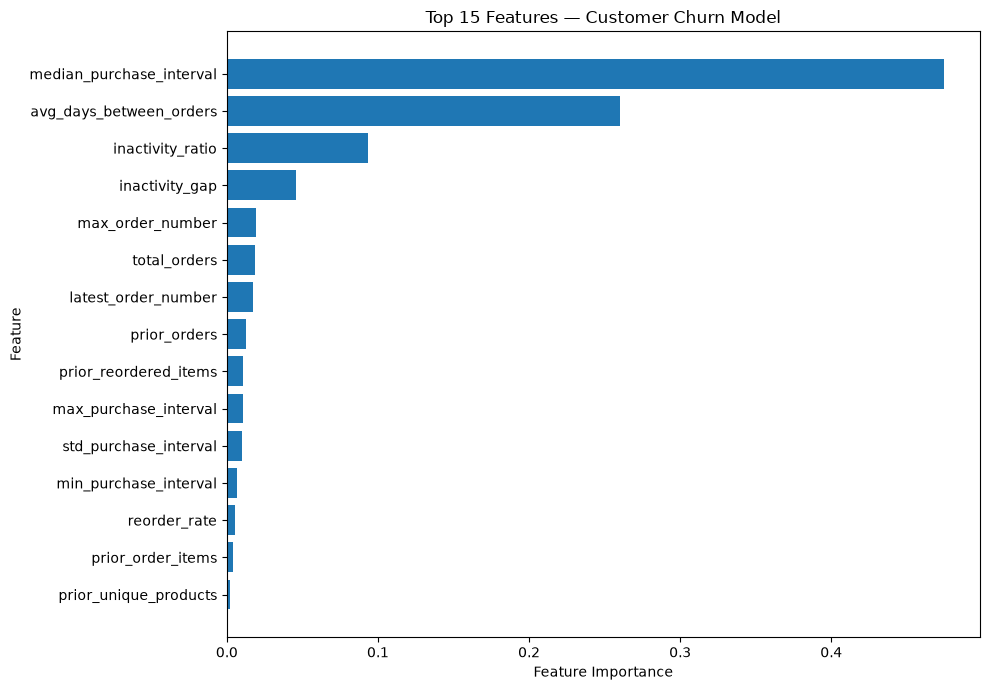

In [112]:
# ============================================================
# Explainability — Feature Importance Visualization
# ============================================================

import matplotlib.pyplot as plt

top_features = (
    explainability_df
    .head(15)
    .sort_values("Importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features — Customer Churn Model")

plt.tight_layout()
plt.show()

### Explainability — SHAP Analysis

SHAP is used to provide model-specific explanations of how individual features influence churn predictions.

SHAP Explainability
------------------------------------------------------------
Samples explained : 2000
Features explained: 23


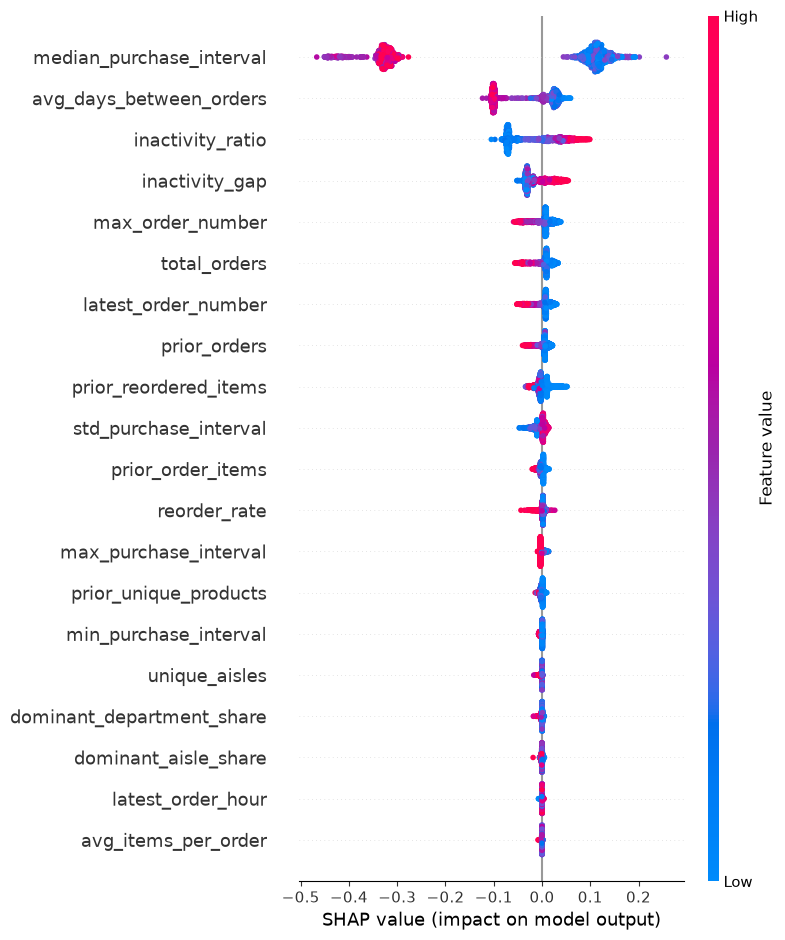

In [114]:
# ============================================================
# Explainability — SHAP Analysis
# ============================================================

import shap

# Use a manageable validation sample for explanation
shap_sample_size = min(2000, len(X_val))

X_shap = X_val.sample(
    n=shap_sample_size,
    random_state=42
)

# Apply the same preprocessing used by the trained pipeline
X_shap_transformed = selected_model.named_steps["imputer"].transform(
    X_shap
)

# Create SHAP TreeExplainer for the trained Random Forest
explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(
    X_shap_transformed
)

# Handle SHAP output format across SHAP versions
if isinstance(shap_values, list):
    shap_values_positive = shap_values[1]
else:
    shap_values_positive = shap_values[:, :, 1]

print("SHAP Explainability")
print("-" * 60)
print(f"Samples explained : {shap_sample_size}")
print(f"Features explained: {X_shap.shape[1]}")

# Global SHAP summary
shap.summary_plot(
    shap_values_positive,
    X_shap_transformed,
    feature_names=X_shap.columns,
    show=True
)

### Explainability — Summary

The explainability analysis shows that customer purchase timing and inactivity-related features are the primary drivers of churn-like predictions. SHAP analysis further indicates how feature values influence the model output, while feature importance provides the overall contribution ranking.